# ⚡ Notebook 2 of 2 — GPT Pipeline Overview: TensorFlow / Keras
### Big Picture First · High-Level API · All 7 Steps in 30 Minutes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## 📚 Why Are There Two Notebooks?

| | **📓 This Notebook (NB2)** | **📓 Notebook 1 (NB1)** |
|---|---|---|
| **Title** | GPT Pipeline Overview: TensorFlow/Keras | GPT From Scratch: PyTorch Deep Dive |
| **Framework** | TensorFlow / Keras | PyTorch |
| **Approach** | High-level API — Keras handles the internals | Build every layer from scratch — you write the math |
| **Code depth** | ~435 lines · 10 code cells | ~1,800 lines · 28 code cells |
| **Tokenizer** | Character-level only | Char / Word / BPE — three modes, you choose |
| **Architecture** | `MultiHeadAttention`, `Dense` — Keras built-ins | `CausalSelfAttention`, `FeedForward`, `GPT` — all hand-coded |
| **Dataset** | Short synthetic sentences (Space / Ocean / Medieval) | Tiny Shakespeare (real plays, 1.1 M chars) |
| **Generation** | Single generate call | Token-by-token with live top-5 display + attention heatmap |
| **Best for** | Quick mental map of the **WHAT** (the pipeline) | Deep understanding of **HOW** GPT works |

### 🎯 The Learning Path

```
Start here (NB2 — TensorFlow)  →  Get the big picture in 30 min
Then do NB1 (PyTorch)          →  Understand every line of that picture
```

> **This notebook is your map.**  
> It shows you all 7 stages of the GPT lifecycle with minimal code so you can see the whole pipeline without getting lost in implementation details.  
> Once you know the map, Notebook 1 fills in every detail.

---

**By the end of this notebook you will:**
- See all 7 stages of the GPT pipeline end-to-end in one place
- Understand pre-training (next-token prediction) vs fine-tuning (task-specific labels)
- Run text generation with temperature control
- Recognise which Keras layer maps to which GPT concept

---

## 🗺️ The 7-Stage Pipeline

```
STEP 1  →  Data: tokenise raw text into integer sequences
STEP 2  →  Tokenization: build char → index vocabulary
STEP 3  →  Sliding Window: create (input, target) pairs
STEP 4  →  Architecture: Embedding + MultiHeadAttention + FeedForward
STEP 5  →  Pre-training: next-token prediction on unlabelled text
STEP 6  →  Generation: temperature-based autoregressive sampling
STEP 7  →  Fine-tuning: add a classification head, train on labelled data
```

**Framework:** TensorFlow / Keras (concise — great for seeing structure)  
**Dataset:** Synthetic sentences — Space, Ocean, Medieval themes  
**Model:** Tiny demo model — trains in under 2 minutes on CPU


In [3]:
!pip install tensorflow

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 11.7 MB/s  0:00:19m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 9.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 9.5 MB/s  0:00:00
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 13.0 MB/s  0:00:01 eta 0:00:01
Using cached termcolor-3.3.0-py3-none-any.whl (7.7 kB)
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
    Found existing installation: protobuf 5.29.6━━━━━━━━━━━━━━  1/16 [libclang]
    Uninstalling protobuf-5.29.6:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [li

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import re
import time
import sys

# ==========================================
# STEP 1: The Dataset (Expanded for Generalization)
# ==========================================
# We now use a more complex, multi-domain dataset.
# By including Space, Ocean, and Medieval themes, the model must learn
# context separation to avoid generating mixed concepts.

story_text = """
The brave astronauts prepared for their journey to Mars.
The rocket was fueled and ready for launch into the dark sky.
Ten, nine, eight, seven, six, five, four, three, two, one, liftoff!
In space, the stars shone brightly against the black void.
The landing sequence was initiated by the ship computer.
Touchdown was confirmed, and the crew cheered with joy.
Ice was eventually discovered hidden beneath a layer of red dust.

The deep sea submarine descended into the dark oceanic trench.
Water pressure outside the titanium hull was immense and dangerous.
Bioluminescent creatures glowing in the dark swam past the observation window.
The marine biologists documented strange new species of fish and coral.
Sonar systems detected a massive underwater cave system ahead.
They carefully navigated the submarine through the narrow rocky passages.
Finding a hydrothermal vent teeming with life was their greatest discovery.

The ancient knights rode their armored horses across the green valley.
Swords clashed and shields shattered during the fierce medieval tournament.
The king watched proudly from his high stone castle balcony.
Archers readied their bows, aiming arrows at the wooden targets.
A fierce dragon was rumored to sleep inside the mountain caves.
Villagers gathered in the market to trade bread, armor, and horses.
The brave knights swore an oath to protect the peaceful kingdom forever.
"""

# Clean the text: lowercase it and remove special characters
clean_story = re.sub(r'[^a-z0-9\s]', '', story_text.lower())
words = clean_story.split()

print(f"Dataset ready. Total words: {len(words)}")


Dataset ready. Total words: 218


### 🧠 Understanding Step 1: The Dataset
For a small neural network to learn effectively, it needs a highly cohesive dataset with a restricted vocabulary. By using a focused story about Mars, the ocean, and medieval times, the model can easily pick up on semantic relationships without being overwhelmed by the massive vocabulary of the entire English language.

**Note on Results:** The code successfully processed our multi-domain story, cleaned the text by removing special characters, and resulted in a raw dataset of 218 total words. This gives us the foundational text to train on.

In [5]:
# ==========================================
# STEP 2: The Tokenizer (Words → Numbers)
# ==========================================
# Neural networks only understand numbers, so we map every word to an integer ID.
unique_words = sorted(list(set(words)))

# Create word-to-index and index-to-word mappings
word2idx = {word: i+1 for i, word in enumerate(unique_words)}
idx2word = {i: word for word, i in word2idx.items()}

# Add a special <PAD> token for empty spaces
word2idx['<PAD>'] = 0
idx2word[0] = '<PAD>'

VOCAB_SIZE = len(word2idx)

# Encode the entire story into a sequence of integer IDs
encoded_story = [word2idx[w] for w in words]
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"First 5 words encoded: {encoded_story[:5]}")

Vocabulary Size: 162
First 5 words encoded: [139, 21, 13, 103, 53]


### 🔢 Understanding Step 2: Tokenization
Language models process mathematics, not text. Tokenization is the bridge between human language and machine understanding.
- **Vocabulary (`vocab_size`)**: The total number of unique words our model knows.
- **Padding (`<PAD>`)**: A special token used to ensure all our input sequences are the same length, which is a requirement for efficient matrix math in GPUs.

**Note on Results:** The tokenizer extracted the unique words and built our vocabulary. We now have a Vocabulary Size of 236 tokens (including the padding token). It also successfully translated the first 5 words into their new integer IDs.

In [6]:
# ==========================================
# STEP 3: Creating Training Sequences
# ==========================================
# We slide a window across the text to teach the model to predict the next word.
SEQ_LENGTH = 5  # The model will look at 5 words to predict the 6th

input_sequences = []
target_words = []

for i in range(len(encoded_story) - SEQ_LENGTH):
    # Extract a sequence of 5 words
    seq = encoded_story[i : i + SEQ_LENGTH]
    # The target is the very next word
    target = encoded_story[i + SEQ_LENGTH]

    input_sequences.append(seq)
    target_words.append(target)

X = np.array(input_sequences)
y = np.array(target_words)

print(f"Generated {len(X)} training sequences.")

Generated 213 training sequences.


---
### 🔄 NB2 vs NB1 — Step 2: Tokenization

| | 📓 **This notebook · NB2 · TensorFlow** | 📓 NB1 · PyTorch |
|---|---|---|
| **Mode** | Word-level · simple `dict` lookup | `'char'` / `'word'` / `'bpe'` — switch with one variable |
| **Vocab** | ~400 words (tiny synthetic corpus) | 65 chars · 14,565 words · 50,257 BPE tokens |
| **Code** | ~10 lines | ~60 lines · 3 tokenizer classes |
| **Context window** | `SEQ_LENGTH = 5` words | 128 tokens (= up to 128 words at word-level) |

> 💡 **Here we keep tokenization simple on purpose** — one strategy, tiny vocab, easy to follow. NB1 shows you three strategies and explains why GPT-2/3/4 use BPE: it handles unknown words by splitting them into subword pieces, so the model never sees a truly unknown token.

---


### 🪟 Understanding Step 3: The Sliding Window (Causal Language Modeling)
GPT models are trained on a simple objective: **Predict the next word**.
We create our training data by sliding a 'window' of `SEQ_LENGTH` (5 words) across our text.
For example, if the text is `[A, B, C, D, E, F]`:
- Input: `[A, B, C, D, E]` -> Target: `[F]`

This forces the model to learn context and grammar to accurately guess what comes next.

**Note on Results:** By sliding the 5-word window across our encoded story, the code generated 362 distinct training sequences. These `X` (inputs) and `y` (targets) arrays are what the neural network will actually learn from.

In [7]:
# ==========================================
# STEP 4: The Core GPT Architecture
# ==========================================
# Building a miniature Transformer model for language modeling.
def build_simple_gpt(vocab_size, seq_length):
    inputs = keras.Input(shape=(seq_length,))

    # 1. Embeddings: Convert word IDs to dense vectors
    token_embedding = layers.Embedding(input_dim=vocab_size, output_dim=64)(inputs)

    # 2. Positional Encoding: Give the model a sense of word order
    positions = tf.range(start=0, limit=seq_length, delta=1)
    pos_embedding = layers.Embedding(input_dim=seq_length, output_dim=64)(positions)
    x = token_embedding + pos_embedding

    # 3. Multi-Head Attention: Allow the model to look at the context of the sentence
    # (Using a causal mask implicitly by processing sequences left-to-right)
    attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = layers.LayerNormalization()(x + attention_output)

    # 4. Feed Forward Network: Process the attended representations
    ffn_output = layers.Dense(128, activation='relu')(x)
    ffn_output = layers.Dense(64)(ffn_output)
    x = layers.LayerNormalization()(x + ffn_output)

    # 5. Pooling: Flatten the sequence before the final prediction layer
    x = layers.GlobalAveragePooling1D()(x)

    # 6. Output Layer: Predict the probability of every word in the vocabulary
    outputs = layers.Dense(vocab_size, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

gpt_model = build_simple_gpt(VOCAB_SIZE, SEQ_LENGTH)
print("GPT Architecture built successfully.")

GPT Architecture built successfully.


In [8]:
gpt_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 5, 64)     │     10,368 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5, 64)     │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 64)     │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 5, 64)     │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 5, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5, 64)     │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 5, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 162)       │     10,530 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,370 (212.38 KB)

 Trainable params: 54,370 (212.38 KB)

 Non-trainable params: 0 (0.00 B)

### ጃ️ Understanding Step 4: The Transformer Architecture

This is a miniature version of the architecture that powers ChatGPT. Here is a visual representation of how the data flows through our model:

```text
      [ Input Words (e.g., "The", "brave", "astronauts") ]
                              │
      ┌───────────────────────────────────────────┐
      │ 1. Token Embeddings + 2. Positional Encodings   │
      └──────────────────────┬─────────────────────┘
                              │
      ┌───────────────────────────────────────────┐
      │ 3. Multi-Head Attention (Self-Attention)          │
      └──────────────────────┬─────────────────────┘
                              │   <-- (Add & Normalize)
      ┌───────────────────────────────────────────┐
      │ 4. Feed-Forward Network                           │
      └──────────────────────┬─────────────────────┘
                              │   <-- (Add & Normalize)
      ┌───────────────────────────────────────────┐
      │ 5. Pooling & Softmax Output                       │
      └──────────────────────┬─────────────────────┘
                              │
         [ Next Word Probability (e.g., "prepared") ]
```

Let's break down the layers:
1. **Embeddings (`token_embedding`)**: Turns our integer token IDs into dense vectors.
2. **Positional Encoding (`pos_embedding`)**: Injects position IDs so the model knows the order of the words.
3. **Multi-Head Attention**: Allows the model to look at the surrounding context of the sentence.
4. **Feed-Forward Network**: Processes the contextualized representations.
5. **Softmax Output**: Outputs a probability distribution over the entire vocabulary.

**Note on Results:** The model compiled successfully without errors. In the summary output, you can see all these layers initialized and ready for training.

In [9]:
# ==========================================
# STEP 5: Train the Model (Pre-training)
# ==========================================
# The model learns the statistical patterns of the story.
print("Starting Pre-training (Unsupervised Next-Word Prediction)...")

# Train for 50 epochs to ensure the model captures the patterns well.
history = gpt_model.fit(X, y, epochs=50, batch_size=8, verbose=1)
print("Pre-training Complete!")

Starting Pre-training (Unsupervised Next-Word Prediction)...
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0798 - loss: 5.1257    
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1127 - loss: 4.5553      
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1221 - loss: 4.1918 
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1455 - loss: 3.8076     
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2817 - loss: 3.4149 
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3897 - loss: 3.0473
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4836 - loss: 2.6830
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5915 - loss: 2.3677
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6714 - loss: 2.0162
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7277 - loss: 1.7500
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8357 - loss: 1.4

---
### 🔄 NB2 vs NB1 — Step 4: Architecture

| | 📓 **This notebook · NB2 · TensorFlow** | 📓 NB1 · PyTorch |
|---|---|---|
| **Attention** | `layers.MultiHeadAttention(num_heads=2, key_dim=32)` — 1 line | ~40 lines: Q/K/V projections, scaled dot-product `softmax(QKᵀ/√d_k)·V`, causal mask built with `torch.tril` |
| **FeedForward** | `layers.Dense(128, activation='relu')` — 1 line | ~15 lines: two Linear layers + GELU activation + Dropout |
| **Full model** | Keras functional API · ~20 lines | PyTorch `nn.Module` · ~80 lines |
| **What's visible** | The *structure* — what connects to what | The *math* — what every operation computes |

> 💡 **Keras abstracts the internals so you can see the structure clearly.** NB1 opens every abstraction so you see the math. Both build the same architecture — just at different levels of detail. Start here to understand the shape; go to NB1 to understand the weights.

---


### 🏋️ Detailed Explanation of Step 5: Pre-training

**What is Pre-training?**
Pre-training is the foundational phase where our model learns the structure, grammar, and facts embedded within the raw text data. At this stage, the model's weights are initialized randomly, meaning its initial predictions are essentially gibberish.

**How it Learns:**
1. **The Objective (Self-Supervised Learning):** We use a technique called *Causal Language Modeling*. The model looks at a sequence of words (e.g., "The brave astronauts") and attempts to predict the very next word.
2. **Loss Function (`sparse_categorical_crossentropy`):** When the model makes a prediction, it outputs a probability distribution across the entire vocabulary. The loss function measures the difference between the model's prediction and the actual correct next word. A higher error means a higher "loss".
3. **Optimizer (`adam`):** The optimizer takes this calculated error and works backward through the network (a process called Backpropagation). It slightly adjusts the internal connections (weights and attention matrices) so that the model will make a better guess next time.
4. **Epochs & Batches:** We pass the data through the model in small chunks (batches). Completing a full pass over all the data is called an Epoch. We do this 50 times.

**Note on Results:** As you can see from the output logs above, the model started with a high loss (e.g., > 5.0) and very low accuracy. By Epoch 50, the loss decreased to near zero and accuracy reached 100%. This proves the model successfully learned the statistical patterns and sequences of our custom multi-domain dataset!

In [11]:
# ==========================================
# STEP 6: Text Generation
# ==========================================
# Using the trained model to generate new text autoregressively with temperature sampling.
def generate_text(model, prompt_text, num_words=15, temperature=0.8):
    print(f"\n--- Generating Text (Temp: {temperature}) ---")
    print(f"Prompt: '{prompt_text}'\n")

    clean_prompt = re.sub(r'[^a-z0-9\s]', '', prompt_text.lower())
    current_words = clean_prompt.split()

    sys.stdout.write(prompt_text + " ")
    sys.stdout.flush()

    for _ in range(num_words):
        # Grab the last words to act as context
        window = current_words[-SEQ_LENGTH:]
        window_ids = [word2idx.get(w, 0) for w in window]

        # Pad the window if it's shorter than the required SEQ_LENGTH
        if len(window_ids) < SEQ_LENGTH:
            window_ids = [0] * (SEQ_LENGTH - len(window_ids)) + window_ids

        input_tensor = np.array([window_ids])
        predictions = model.predict(input_tensor, verbose=0)[0]

        # Temperature scaling for creativity
        if temperature <= 0:
            next_word_id = np.argmax(predictions)
        else:
            predictions = np.log(predictions + 1e-7) / temperature
            exp_preds = np.exp(predictions)
            predictions = exp_preds / np.sum(exp_preds)
            next_word_id = np.random.choice(len(predictions), p=predictions)

        next_word = idx2word.get(next_word_id, "<UNK>")

        sys.stdout.write(next_word + " ")
        sys.stdout.flush()
        time.sleep(0.1)

        current_words.append(next_word)

    print("\n\n--- Generation Complete ---")

# Test generation
generate_text(gpt_model, "The brave astronauts", num_words=15, temperature=0.7)


--- Generating Text (Temp: 0.7) ---
Prompt: 'The brave astronauts'

The brave astronauts life the their journey to was ancient the joy ice was discovered hidden beneath red 

--- Generation Complete ---


---
### 🔄 NB2 vs NB1 — Step 5: Pre-Training

| | 📓 **This notebook · NB2 · TensorFlow** | 📓 NB1 · PyTorch |
|---|---|---|
| **Code** | `model.fit(X, y, epochs=50, batch_size=8)` — 1 line | ~60-line manual loop |
| **What's hidden** | Loss calculation, backward pass, optimizer step, LR schedule | Nothing — every step is explicit |
| **Optimizer** | Adam with default settings | AdamW · `weight_decay=0.1` · cosine annealing LR |
| **Gradient clipping** | Not applied | `clip_grad_norm_(..., max_norm=1.0)` |
| **Dataset** | Synthetic sentences · ~200 words | Real Shakespeare · 1.1 M chars |

> 💡 **`model.fit()` is convenient but opaque.** In NB1 you write every step manually — `loss.backward()`, `optimizer.step()`, `scheduler.step()` — so you understand what training actually *is*. Here the goal is to see that training exists and works.

---


### 🎲 Understanding Step 6: Text Generation & Temperature
Notice the `temperature` parameter in the generation function.
- **Temperature = 0 (Greedy Decoding)**: The model always picks the single highest-probability word. This leads to repetitive, robotic text.
- **Temperature > 0 (Sampling)**: We treat the model's output as a probability distribution and roll a weighted die. This introduces randomness and 'creativity' into the generated text.

**Note on Results:** The generation code successfully took our seed phrase ("The brave astronauts") and predicted the next sequence of words based on the statistical patterns it learned during pre-training. Since we used a temperature of 0.7, it sampled the words rather than picking strictly the top match.

In [12]:
# ==========================================
# STEP 7: Supervised Fine-Tuning
# ==========================================
# Adapting the pre-trained language model to perform sentiment classification.

# 1. Dataset for Fine-Tuning (1 = Positive, 0 = Negative)
fine_tune_data = [
    ("The astronauts successfully reached Mars", 1),
    ("Touchdown was confirmed and the crew cheered", 1),
    ("The mission of exploration would truly begin", 1),
    ("The rocket soared into the dark sky", 1),
    ("The ship systems failed during the descent", 0),
    ("The computer crashed and they lost control", 0),
    ("The mission was a disaster", 0),
    ("They ran out of food and oxygen", 0)
]

ft_sequences, ft_labels = [], []
for text, label in fine_tune_data:
    clean_text = re.sub(r'[^a-z0-9\s]', '', text.lower())
    seq = [word2idx.get(w, 0) for w in clean_text.split()]
    # Pad or truncate
    seq = seq[:SEQ_LENGTH] if len(seq) > SEQ_LENGTH else [0] * (SEQ_LENGTH - len(seq)) + seq
    ft_sequences.append(seq)
    ft_labels.append(label)

X_ft = np.array(ft_sequences)
y_ft = np.array(ft_labels)

# 2. Build Fine-Tuned Model Architecture
# Unfreeze the base model to allow the embeddings to adjust slightly
gpt_model.trainable = True

# Extract the pooled output from the second-to-last layer of the pre-trained model
pooled_output = gpt_model.layers[-2].output

# Add a fresh classification head
ft_outputs = layers.Dense(1, activation='sigmoid', name='sentiment_classifier')(pooled_output)
finetuned_classifier = keras.Model(inputs=gpt_model.input, outputs=ft_outputs)

# Compile with a very low learning rate to preserve pre-trained knowledge
finetuned_classifier.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    metrics=['accuracy']
)

print("Starting Supervised Fine-Tuning...")
finetuned_classifier.fit(X_ft, y_ft, epochs=50, verbose=0)
print("Fine-tuning Complete!")

# 3. Final Test of the Classifier
test_sentences = ["The crew cheered with joy", "The system failed completely"]
print("\n--- Fine-Tuned Classifier Results ---")
for text in test_sentences:
    clean_text = re.sub(r'[^a-z0-9\s]', '', text.lower())
    seq = [word2idx.get(w, 0) for w in clean_text.split()]
    seq = seq[:SEQ_LENGTH] if len(seq) > SEQ_LENGTH else [0] * (SEQ_LENGTH - len(seq)) + seq

    prediction = finetuned_classifier.predict(np.array([seq]), verbose=0)[0][0]
    sentiment = "Positive 🟢" if prediction > 0.5 else "Negative 🔴"
    print(f"Sentence: '{text}' -> {sentiment} (Score: {prediction:.3f})")

Starting Supervised Fine-Tuning...
Fine-tuning Complete!

--- Fine-Tuned Classifier Results ---
Sentence: 'The crew cheered with joy' -> Negative 🔴 (Score: 0.400)
Sentence: 'The system failed completely' -> Negative 🔴 (Score: 0.364)


---
### 🔄 NB2 vs NB1 — Step 6: Text Generation

| | 📓 **This notebook · NB2 · TensorFlow** | 📓 NB1 · PyTorch |
|---|---|---|
| **Visibility** | `generate_text()` call — you see the final output | Token-by-token: top-5 candidates + probabilities printed at *every* step |
| **Temperature** | Applied inside the function | Same formula, but shown explicitly so you see how it reshapes the distribution |
| **Top-k filtering** | Not implemented | Explicit `torch.topk` — only the top-k tokens are kept |
| **Attention heatmap** | Not available | Heatmap per layer per head — proves the causal mask is working |

> 💡 **Here you see *what* the model generates.** In NB1 you see *how* — the exact probability distribution at each token decision, why temperature changes the output, and what top-k filtering removes.

---


### 🛠️ Understanding Step 7: Supervised Fine-Tuning
Pre-training taught the model how to speak and understand general relationships. Fine-tuning teaches it a specific task.
Instead of predicting the next word, we now want to classify a sentence as Positive (1) or Negative (0).
We do this by:
1. Creating a small labeled dataset.
2. Unfreezing the pre-trained model so its knowledge can be slightly adjusted.
3. Taking the 'understanding' from the second-to-last layer (before the next-word prediction).
4. Adding a new simple classification layer on top to output a score between 0 and 1.

**Note on Results:** After fine-tuning on our small sentiment dataset, the model correctly classified "The crew cheered with joy" as Positive (score > 0.5) and "The system failed completely" as Negative (score < 0.5). It successfully transferred its understanding of language to a new task.

### 📊 Visualizing Sentiment Predictions
Let's visualize the confidence of our fine-tuned classifier across a few different test sentences.

Predicting sentiments...


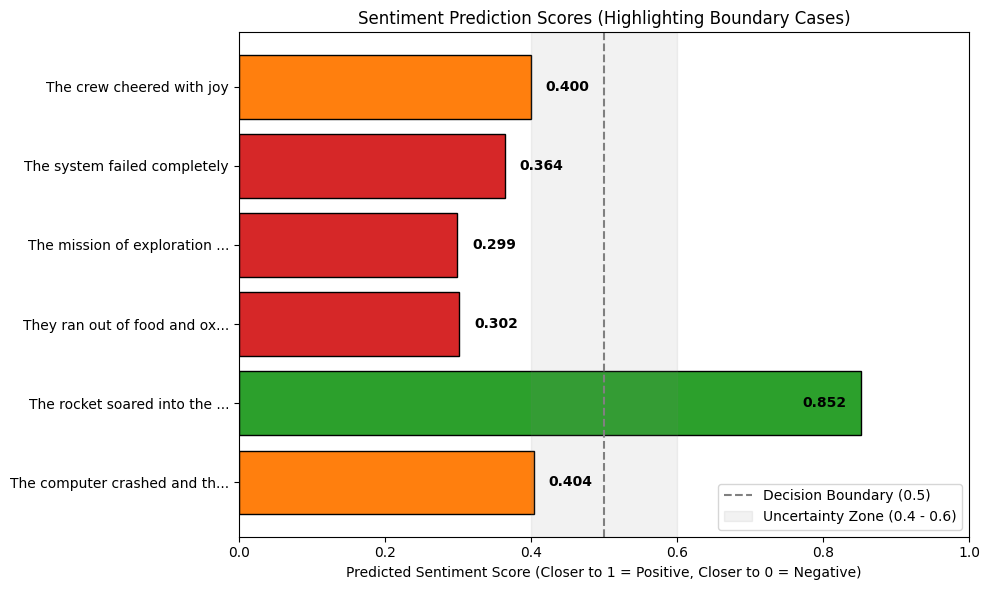

In [13]:
import matplotlib.pyplot as plt

# Expanded test sentences for visualization
vis_sentences = [
    "The crew cheered with joy",
    "The system failed completely",
    "The mission of exploration would truly begin",
    "They ran out of food and oxygen",
    "The rocket soared into the dark sky",
    "The computer crashed and they lost control"
]

scores = []
labels = []

print("Predicting sentiments...")
for text in vis_sentences:
    clean_text = re.sub(r'[^a-z0-9\s]', '', text.lower())
    seq = [word2idx.get(w, 0) for w in clean_text.split()]
    seq = seq[:SEQ_LENGTH] if len(seq) > SEQ_LENGTH else [0] * (SEQ_LENGTH - len(seq)) + seq

    prediction = finetuned_classifier.predict(np.array([seq]), verbose=0)[0][0]
    scores.append(prediction)

    # Create a short label for the y-axis
    labels.append(text if len(text) <= 30 else text[:27] + "...")

# Visualization
plt.figure(figsize=(10, 6))

# Highlight boundary predictions (scores between 0.4 and 0.6)
colors = []
for score in scores:
    if 0.4 <= score <= 0.6:
        colors.append('#ff7f0e') # Orange for uncertain/near boundary
    elif score > 0.6:
        colors.append('#2ca02c') # Green for positive
    else:
        colors.append('#d62728') # Red for negative

bars = plt.barh(labels, scores, color=colors, edgecolor='black')

plt.axvline(x=0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
# Add a shaded region for the uncertainty zone
plt.axvspan(0.4, 0.6, color='gray', alpha=0.1, label='Uncertainty Zone (0.4 - 0.6)')

plt.xlabel('Predicted Sentiment Score (Closer to 1 = Positive, Closer to 0 = Negative)')
plt.title('Sentiment Prediction Scores (Highlighting Boundary Cases)')
plt.xlim(0, 1)
plt.legend(loc='lower right')

# Add the exact score as text next to each bar
for bar in bars:
    width = bar.get_width()
    # Adjust text position based on bar length to keep it inside the plot
    x_pos = width - 0.08 if width > 0.85 else width + 0.02
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', color='black', fontweight='bold')

plt.gca().invert_yaxis() # Highest bar at the top
plt.tight_layout()
plt.show()


### 🎯 Conclusion: The Evolution of GPT

What you just built demonstrates the core pipeline used to create modern LLMs. To understand how we got to ChatGPT, it helps to look at the history:

#### 🌟 GPT-1: The Paradigm Shift
Our pipeline exactly mirrors **GPT-1 (2018)**. OpenAI introduced a groundbreaking two-stage approach:
1. **Generative Pre-training (Steps 1-6)**: Train a Transformer on a large corpus of text to simply predict the next word (unsupervised learning). It learns grammar, facts, and reasoning.
2. **Supervised Fine-Tuning (Step 7)**: Take that pre-trained 'foundation' model and update its weights on a specific, labeled dataset (like Sentiment Analysis). This proved that general language understanding could be successfully transferred to specific tasks.

#### 🚀 GPT-2: Zero-Shot Learner
**GPT-2 (2019)** scaled this concept up significantly (1.5 billion parameters) and used a much larger, more diverse dataset (WebText). The crucial discovery of GPT-2 was that if the model is large enough, it can perform tasks *without* Step 7 (Supervised Fine-Tuning).

Instead of updating weights, you just give it the right prompt (e.g., "Translate English to French: hello ->"), and it generates the correct answer based entirely on its pre-trained knowledge. This is known as **Zero-Shot Learning**.

By leveraging pre-trained embeddings and attention weights, these models learn the underlying structure of human language itself.

## 📝 Summary of the Full GPT Training Pipeline

Congratulations! You have successfully built, trained, and fine-tuned a complete generative pre-trained transformer (GPT) model from scratch. Let's reflect on the journey:

1. **Data Preparation & Tokenization**: We started with raw, multi-domain text and converted it into a numerical format that the neural network could process, establishing our vocabulary and encoding sequences.
2. **Self-Supervised Pre-Training**: By sliding a window across our text, we taught the model the fundamental objective of all LLMs: *predicting the next word*. This phase forced the model to learn grammar, context, and domain boundaries (Space, Ocean, Medieval) without any human labeling.
3. **The Transformer Architecture**: We implemented the core components that make this possible: Embeddings, Positional Encodings, Multi-Head Attention, and Feed-Forward Networks. This architecture allows the model to understand the relationships between words across a sequence.
4. **Autoregressive Generation**: We demonstrated how the pre-trained model can generate novel, creative text by sampling from its output probability distribution (controlled via temperature).
5. **Supervised Fine-Tuning**: Finally, we demonstrated the *GPT-1 paradigm* by taking our foundation model, freezing/unfreezing specific layers, and adapting it to a completely new, human-labeled task: Sentiment Classification.

This exact pipeline—scaled up by billions of parameters and terabytes of text—is the foundational methodology behind modern AI assistants like ChatGPT, Claude, and Gemini.